# Computer Vision - Part 8

## Inverse Kinematics in Robotics

Inverse kinematics is the process of computing the joint values required for a robot manipulator to reach a desired end-effector pose. In robotics, this is essential for tasks like positioning, grasping, and trajectory planning, because the robot must convert a target pose in space into the corresponding joint angles.

Unlike forward kinematics, which maps joint angles to end-effector position and orientation, inverse kinematics works in the reverse direction and often has multiple solutions or no solution at all. The equations can be nonlinear and coupled, so numerical methods are typically used to find a feasible joint configuration.

The Levenberg-Marquardt algorithm is a popular solver for inverse kinematics because it blends gradient descent and Gauss-Newton optimization. It updates the joint vector using the formula:

$$\delta q = (J^T J + \lambda^2 I)^{-1} J^T e$$

where $J$ is the Jacobian matrix, $\lambda$ is the damping factor, $I$ is the identity matrix, and $e$ is the pose error vector.

Damping helps to stabilize the solution and avoid large jumps in joint angles, especially when the Jacobian is near singular. The algorithm iteratively updates the joint angles until the pose error is minimized or a maximum number of iterations is reached.

In [94]:
import roboticstoolbox as rtb
from spatialmath import SE3
import numpy as np

# Load robot model
robot = rtb.models.URDF.Panda()

# Define desired end-effector pose
T_des = SE3(0.5, 0.0, 0.3) * SE3.Rx(np.deg2rad(90))

# Solve IK using Levenberg-Marquardt
sol = robot.ikine_LM(T_des, q0=robot.qr)
q_sol = sol.q
print("success =", sol.success, "; iterations =", sol.iterations, "; residual =", sol.residual)

# Verify with FK
T_check = robot.fkine(q_sol)
print("T_check:\n", T_check.A)
print("position error:", T_check.t - T_des.t)

success = True ; iterations = 7 ; residual = 2.4951301104435843e-08
T_check:
 [[ 1.00000000e+00 -6.10612495e-09 -2.82968857e-08  4.99999986e-01]
 [-2.82968854e-08  3.94599364e-08 -1.00000000e+00 -1.00868050e-08]
 [ 6.10612625e-09  1.00000000e+00  3.94599362e-08  2.99999984e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
position error: [-1.40199561e-08 -1.00868050e-08 -1.60344030e-08]


In [95]:
print("rotation error:\n", T_check.R - T_des.R)

rotation error:
 [[-5.55111512e-16 -6.10612495e-09 -2.82968857e-08]
 [-2.82968854e-08  3.94599364e-08  1.22124533e-15]
 [ 6.10612625e-09 -8.88178420e-16  3.94599362e-08]]


### Impact of Initial Guess q₀. 

This value is automatically set to the current joint angles of the robot, which can help the algorithm converge faster if the target pose is close to the current pose. However, if the target pose is far from the current pose, a poor initial guess can lead to slow convergence or getting stuck in local minima.

- Good q₀ (Near Solution): The algorithm starts in a region where the cost function is well-behaved. It converges quickly, in few iterations, to the desired solution — typically the one nearest to the current robot pose.

- Poor q₀ (Far from Solution): Convergence is slow, and the optimizer may settle into a different local minimum (a different IK solution), or fail to converge entirely if the starting point is near a singularity.

### Inverse Kinematics for Mobile Robots

The concept of Inverse Kinematics extends naturally to mobile robots. Instead of finding joint angles, the goal is to find wheel velocity commands `(vL, vR)` that produce a desired body motion `(v, ω)`. This is the "IK" of the differential-drive platform.

- State: `(x, y, θ)` — position and heading in the world frame
- Control inputs: `v` (forward speed), `ω` (angular rate)

Differential Drive "IK" — `(v, ω) → (vL, vR)`
For a differential-drive robot with wheel track width W, the forward kinematics from wheel speeds to body motion is:

$$V = \frac{V_L + V_R}{2}, \quad \omega = \frac{V_R - V_L}{W}$$


Inverting these equations gives the "IK" of the mobile base — from desired (v, ω) to wheel commands:

$$V_L = V - \frac{\omega W}{2}, \quad V_R = V + \frac{\omega W}{2}$$

This is a linear, closed-form inversion — no iteration needed. The mobile IK is always unique (unlike arm IK) as long as
hardware limits are respected.

The following function is used in the mobile robot lab to compute wheel commands from a desired trajectory. It is also the final output stage in the line-following pipeline: `error → ω → diff_drive_ik → (vL, vR) → motors`.

In [96]:
def diff_drive_ik(v, w, W):
    """
    Convert desired body velocity (v, w) to wheel speeds (v_L, v_R).
    Args:
    v : forward speed [m/s]
    w : angular rate [rad/s]
    W : wheel track width [m]
    Returns:
    v_L, v_R : left and right wheel speeds [m/s]
    """
    v_R = v + w * W / 2
    v_L = v - w * W / 2
    return v_L, v_R

v = 0.5  # forward speed in m/s
w = 0.2  # angular rate in rad/s
W = 0.3  # wheel track width in m
v_L, v_R = diff_drive_ik(v, w, W)
print("Left wheel speed (v_L):", v_L, "m/s")
print("Right wheel speed (v_R):", v_R, "m/s")

Left wheel speed (v_L): 0.47 m/s
Right wheel speed (v_R): 0.53 m/s


### Lab 1 - Analytic IK (2R)

What to do: Implement geometric IK from scratch. 

Derive and implement the complete analytic IK for a 2R planar robot using the law of cosines and atan2 formula — no library calls, only geometry and NumPy.

Specification
- Input: `l₁, l₂, (xd, yd)`
- Output: 0, 1, or 2 solutions `(θ₁, θ₂)` with elbow classification

In [97]:
import numpy as np

def ik_2r(l1, l2, x, y):
    """Returns list of (theta1, theta2) solutions."""
    r2 = x**2 + y**2
    cos_t2 = (r2 - l1**2 - l2**2) / (2 * l1 * l2)
    if abs(cos_t2) > 1.0:
        return [] # Target unreachable

    def compute_theta1(theta2):
        phi = np.arctan2(y, x)
        beta = np.arctan2(l2 * np.sin(theta2),
        l1 + l2 * np.cos(theta2))
        return phi - beta

    t2_down = +np.arccos(cos_t2) # elbow-down
    t2_up = -np.arccos(cos_t2) # elbow-up
    sols = []

    for t2, label in [(t2_down, "elbow-down"), (t2_up, "elbow-up")]:
        t1 = compute_theta1(t2)
        sols.append((t1, t2, label))
        
    return sols

Plot both arm configurations on the same axes using matplotlib to visually confirm the two solutions reach the same `(x_d, y_d)`.

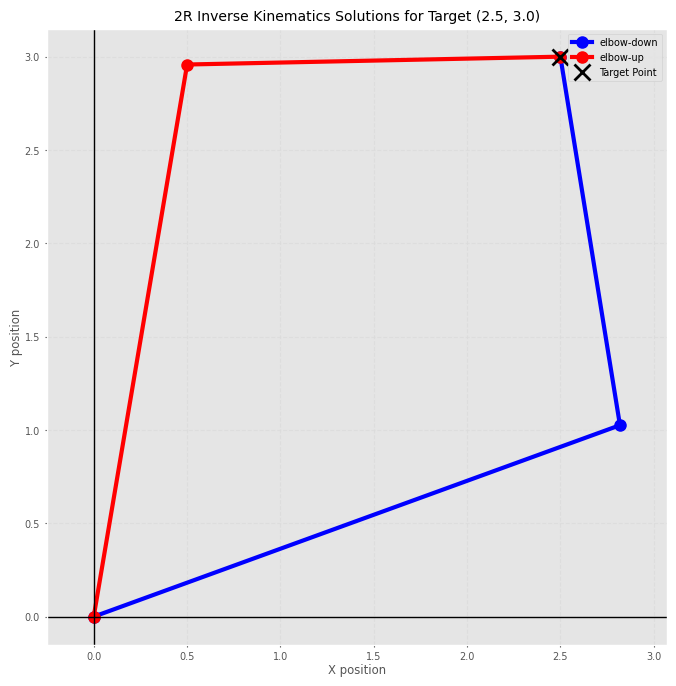

In [98]:
import matplotlib.pyplot as plt

l1, l2 = 3.0, 2.0
x_d, y_d = 2.5, 3.0

solutions = ik_2r(l1, l2, x_d, y_d)

# Plotting
plt.figure(figsize=(8, 8))
colors = {'elbow-down': 'blue', 'elbow-up': 'red'}

for t1, t2, label in solutions:
    # Coordinates of the elbow (Joint 2)
    x1 = l1 * np.cos(t1)
    y1 = l1 * np.sin(t1)
    
    # Coordinates of the end-effector
    x2 = x1 + l2 * np.cos(t1 + t2)
    y2 = y1 + l2 * np.sin(t1 + t2)
    
    # Plot links and joints
    plt.plot([0, x1, x2], [0, y1, y2], '-o', label=label, color=colors[label], linewidth=3, markersize=8)

# Plot the target point for confirmation
plt.plot(x_d, y_d, 'kx', markersize=12, markeredgewidth=2, label='Target Point')

plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.legend()
plt.title(f'2R Inverse Kinematics Solutions for Target ({x_d}, {y_d})')
plt.axis('equal')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.show()

### Lab 2 - Numerical IK for 6-DOF Arm (Panda / Yahboom)

Use `ikine_LM` to solve IK for 3–5 distinct target poses. Verify each
solution using FK, compute and report position and orientation errors.

Task:
- Select 3–5 simple Tdes poses (vary x, y, z and light rotations)
- Solve IK with `q0 = robot.qr`
- Print Tdes, Tcheck, position error vector
- Record sol.success, sol.iterations, sol.residual

In [99]:
targets = [SE3(0.5, 0.0, 0.3), 
           SE3(0.4, 0.2, 0.25) * SE3.Rz(np.deg2rad(30)), 
           SE3(0.45, -0.15, 0.28)]

q0 = robot.qr

for T_des in targets:
    sol = robot.ikine_LM(T_des, q0=q0)
    q_sol = sol.q
    T_check = robot.fkine(q_sol)
    err = T_check.t - T_des.t
    print(sol.success, sol.iterations, err)

True 17 [-6.41901277e-09 -3.47289174e-09 -1.59089053e-09]
True 13 [ 3.68804987e-12 -1.05189746e-11 -1.37340139e-12]
True 20 [-4.23973837e-08 -3.56620580e-07  2.07326422e-07]


**IK with Joint Limits & Workspace Boundary**

- Choose target poses Tdes near or outside the robot's reachable workspace — pushing the arm to its kinematic limits.

In [100]:
targets = [SE3(1.2, 0.5, 0.5), # Way out of reach (Distance ~1.5m), 
           SE3(0.9, 0.0, 0.3) * SE3.Ry(np.deg2rad(90)), # At the absolute boundary (Distance ~0.95m), 
           SE3(0.05, 0.0, 0.8)] # Near the base singularity (Reach very tight to the column)

q0 = robot.qr

for T_des in targets:
    sol = robot.ikine_LM(T_des, q0=q0)
    q_sol = sol.q
    T_check = robot.fkine(q_sol)
    err = T_check.t - T_des.t
    print(sol.success, sol.iterations, err)

False 3000 [-0.58976531 -0.24574112  0.02526154]
False 1258 [-2.27912922e-08 -1.00311712e-08 -1.02281523e-08]
False 1588 [-5.37552267e-10  2.02471249e-10 -2.93029156e-10]


- Watch for `sol.success = False` or joint solutions `q_sol` that violate the robot's joint limits. Record which targets cause failure.

In [101]:
for idx, T_des in enumerate(targets, start=1):
    sol = robot.ikine_LM(T_des, q0=q0)
    q_sol = sol.q
    T_check = robot.fkine(q_sol)
    err = T_check.t - T_des.t
    status = "SUCCESS" if sol.success else "FAILURE"
    print(f"Target {idx}: {status}, iterations={sol.iterations}, position error={err}")
    if not sol.success:
        print(f"  -> Target {idx} failed to converge for pose:\n{T_des}")

Target 1: FAILURE, iterations=3000, position error=[-0.43674248 -0.18198769  0.01348081]
  -> Target 1 failed to converge for pose:
   1         0         0         1.2       
   0         1         0         0.5       
   0         0         1         0.5       
   0         0         0         1         

Target 2: FAILURE, iterations=1379, position error=[-1.48166934e-09 -1.82100544e-07 -9.90449800e-07]
  -> Target 2 failed to converge for pose:
   0         0         1         0.9       
   0         1         0         0         
  -1         0         0         0.3       
   0         0         0         1         

Target 3: FAILURE, iterations=1544, position error=[ 2.44620331e-10  1.34159899e-10 -8.82119600e-10]
  -> Target 3 failed to converge for pose:
   1         0         0         0.05      
   0         1         0         0         
   0         0         1         0.8       
   0         0         0         1         



Mark successful and failed targets on a 2D or 3D plot of the TCP workspace. Identify the reachable boundary visually.

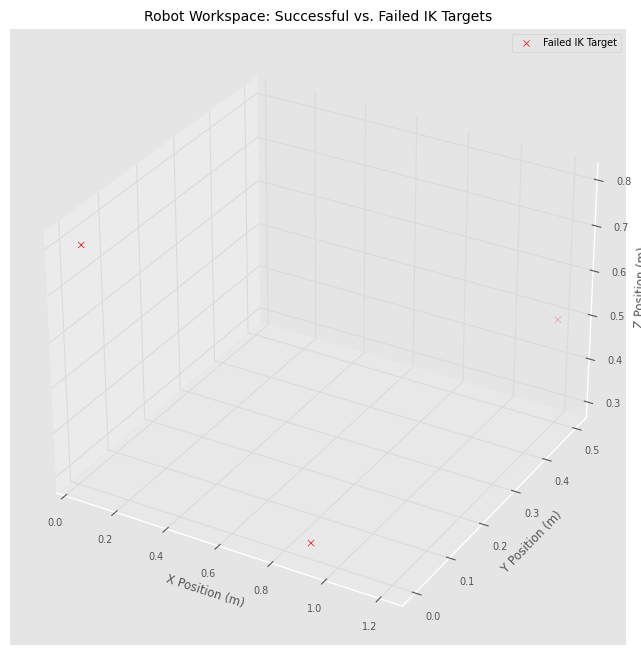

In [102]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

successful_targets = []
failed_targets = []

for T_des in targets:
    sol = robot.ikine_LM(T_des, q0=q0)
    if sol.success:
        successful_targets.append(T_des.t)
    else:
        failed_targets.append(T_des.t)

successful_targets = np.array(successful_targets)
failed_targets = np.array(failed_targets)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

if successful_targets.shape[0] > 0:
    ax.scatter(successful_targets[:, 0], successful_targets[:, 1], successful_targets[:, 2], c='g', marker='o', label='Successful IK Target')
if failed_targets.shape[0] > 0:
    ax.scatter(failed_targets[:, 0], failed_targets[:, 1], failed_targets[:, 2], c='r', marker='x', label='Failed IK Target')

ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_zlabel('Z Position (m)')
ax.set_title('Robot Workspace: Successful vs. Failed IK Targets')
ax.legend()
ax.grid(True)
plt.show()

- Selecting IK Solution Closest to Current Config: For the same target Tdes, solve IK twice.

In [103]:
q_cur = robot.qr # Assuming the robot is currently in its 'ready' configuration
T_des_compare = SE3(0.5, 0.0, 0.3) # Using a previously successful target pose

# Run 1: q0 = robot.qz (zero configuration)
sol_qz = robot.ikine_LM(T_des_compare, q0=robot.qz)
q_sol_qz = sol_qz.q
print("success (qz) =", sol_qz.success, "; iterations (qz) =", sol_qz.iterations, "; residual (qz) =", sol_qz.residual)
dist_qz_to_qcur = np.linalg.norm(q_sol_qz - q_cur)
# compute ‖qsol − qcur|| for each run
print(f"Distance ||q_sol - q_cur|| (from qz): {dist_qz_to_qcur:.4f}")

# Run 2: q0 = q_cur (current robot pose)
sol_qcur = robot.ikine_LM(T_des_compare, q0=q_cur)
q_sol_qcur = sol_qcur.q
print("success (qcur) =", sol_qcur.success, "; iterations (qcur) =", sol_qcur.iterations, "; residual (qcur) =", sol_qcur.residual)
dist_qcur_to_qcur = np.linalg.norm(q_sol_qcur - q_cur)
# compute ‖qsol − qcur|| for each run
print(f"Distance ||q_sol - q_cur|| (from q_cur): {dist_qcur_to_qcur:.4f}")

# Compare the resulting q_sol for each run.
print("\nComparison of results:")
print(f"q_sol from qz: {q_sol_qz}")
print(f"q_sol from q_cur: {q_sol_qcur}")

success (qz) = True ; iterations (qz) = 58 ; residual (qz) = 1.198566083239986e-09
Distance ||q_sol - q_cur|| (from qz): 4.4986
success (qcur) = True ; iterations (qcur) = 17 ; residual (qcur) = 1.604207268420401e-08
Distance ||q_sol - q_cur|| (from q_cur): 3.1634

Comparison of results:
q_sol from qz: [ 2.47445984 -1.04824781 -2.64290893 -2.03437288  1.82148133  0.44207652
 -0.10758279]
q_sol from q_cur: [ 0.39988856  0.95102607 -0.25280491 -2.07292652 -2.13842452  0.24387907
  1.5239163 ]


Always set `q0 = q_cur` in operational code.

### Lab 3: FK–IK Consistency Check

This lab verifies the mathematical consistency of FK and IK by testing the round-trip property: FK(IKF(K(q))) ≈ FK(q).

- Step 1: Random Configs - Sample several joint configurations `q_random` uniformly within the robot's joint limits using `np.random.uniform`.

In [104]:
def sample_random_configs(num_samples, joint_limits):
    """
    Samples random joint configurations within the robot's joint limits.

    Args:
        num_samples (int): Number of configurations to sample.
        joint_limits (np.ndarray): An (N, 2) array where N is the number of joints,
                                   and each row is [min_limit, max_limit].

    Returns:
        np.ndarray: An (num_samples, N) array of random configurations.
    """
    
    num_joints = joint_limits.shape[0]
    lower_limits = joint_limits[:, 0]
    upper_limits = joint_limits[:, 1]
    
    # Generate random values between 0 and 1
    random_samples = np.random.uniform(0, 1, size=(num_samples, num_joints))
    
    # Scale and shift samples to joint limits: low + (high - low) * random[0,1]
    q_random = lower_limits + (upper_limits - lower_limits) * random_samples
    
    return q_random

- Step 2: FK → IK: Compute `T = robot.fkine(q_random)`, then solve `q' = ikine_LM(T, q0=q_random)`.

- Step 3: Compare - Compute `‖q' − q_random‖`. For non-redundant robots this should be near zero. For redundant robots (7-DOF), small differences are expected. This should recover the original or equivalent configuration.

In [105]:
# Define joint limits for the Panda robot
# Assuming robot.qlim is available and provides [lower_bound, upper_bound] for each joint
joint_limits = np.array([robot.qlim[0], robot.qlim[1]]).T

num_samples = 5 # Number of random configurations to test
random_configs = sample_random_configs(num_samples, joint_limits)

print("FK -> IK Verification (Random Configurations):")
print("---------------------------------------------------")

for i, q_rand in enumerate(random_configs):
    # Step 2: FK -> IK
    T_rand = robot.fkine(q_rand) # Compute Forward Kinematics
    sol_ik = robot.ikine_LM(T_rand, q0=q_rand) # Solve IK with q_rand as initial guess
    q_prime = sol_ik.q

    # Step 3: Compare
    diff_norm = np.linalg.norm(q_prime - q_rand)

    print(f"\nSample {i+1}:")
    print(f"  Original q_random: {np.round(q_rand, 4)}")
    print(f"  Recovered q_prime: {np.round(q_prime, 4)}")
    print(f"  Success: {sol_ik.success}, Iterations: {sol_ik.iterations}, Residual: {sol_ik.residual:.2e}")
    print(f"  Euclidean distance ||q_prime - q_random||: {diff_norm:.4f}")
    if sol_ik.success and diff_norm < 1e-3:
        print("  -> IK successfully recovered the original configuration (or an equivalent).")
    elif sol_ik.success:
        print("  -> IK converged, but found a different, valid configuration.")
    else:
        print("  -> IK failed to converge.")

FK -> IK Verification (Random Configurations):
---------------------------------------------------

Sample 1:
  Original q_random: [ 2.0097  0.0418  0.398  -1.5618 -0.9983  0.0659  2.0064]
  Recovered q_prime: [ 2.0097  0.0418  0.398  -1.5618 -0.9983  0.0659  2.0064]
  Success: True, Iterations: 1, Residual: 0.00e+00
  Euclidean distance ||q_prime - q_random||: 0.0000
  -> IK successfully recovered the original configuration (or an equivalent).

Sample 2:
  Original q_random: [ 2.5077 -1.2212 -2.2028 -1.01   -0.4795  0.9198 -2.1933]
  Recovered q_prime: [ 2.5077 -1.2212 -2.2028 -1.01   -0.4795  0.9198 -2.1933]
  Success: True, Iterations: 1, Residual: 0.00e+00
  Euclidean distance ||q_prime - q_random||: 0.0000
  -> IK successfully recovered the original configuration (or an equivalent).

Sample 3:
  Original q_random: [-1.35   -1.0257 -2.4753 -1.7395  0.4627  1.0736  2.7442]
  Recovered q_prime: [-1.35   -1.0257 -2.4753 -1.7395  0.4627  1.0736  2.7442]
  Success: True, Iterations: 1, 

**Mini Trajectory Around a Target — IK-Planned**

Choose a center pose T₀ in the middle of the workspace. Generate a set of nearby poses:

- Translate by ±1–2 cm along x, y, z axes

- Rotate by ±5° around each axis

Solve IK for each pose to get joint configurations qi.

In [106]:
import numpy as np
from spatialmath import SE3

# 1. Define Center Pose (T0)
# Example: 40cm forward, 0cm side, 50cm up
T0 = SE3.Trans(0.4, 0.0, 0.5) * SE3.RPY(0, np.pi, 0) 

# 2. Define Ranges
translations = [0.01, -0.01, 0.02, -0.02] # meters
rotations = np.deg2rad([5, -5])           # radians

target_poses = []

# Generate Translation variations
for axis in ['x', 'y', 'z']:
    for val in translations:
        if axis == 'x': offset = SE3.Trans(val, 0, 0)
        if axis == 'y': offset = SE3.Trans(0, val, 0)
        if axis == 'z': offset = SE3.Trans(0, 0, val)
        target_poses.append(T0 * offset)

# Generate Rotation variations
for axis in ['rx', 'ry', 'rz']:
    for val in rotations:
        if axis == 'rx': offset = SE3.Rx(val)
        if axis == 'ry': offset = SE3.Ry(val)
        if axis == 'rz': offset = SE3.Rz(val)
        target_poses.append(T0 * offset)

print(f"Generated {len(target_poses)} target poses.")

Generated 18 target poses.


**Visualization**

Compute FK for each qi and plot the resulting TCP positions in 3D space. Observe how small task-space perturbations map to joint-space changes. This illustrates the local geometry of the FK/IK mapping and is a precursor to trajectory planning covered in later weeks.

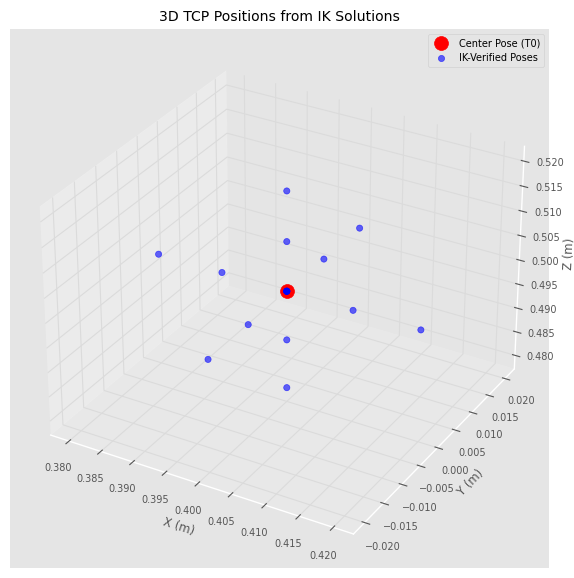

In [107]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# List to store TCP positions (x, y, z) from successful IK solutions
reachable_tcp_positions = []

# Assuming 'target_poses' and 'robot' are defined from previous cells
# Use q0 = robot.qr as a common initial guess for consistency
q0_ik = robot.qr

for i, T_des in enumerate(target_poses):
    sol = robot.ikine_LM(T_des, q0=q0_ik)
    if sol.success:
        q_sol = sol.q
        T_check = robot.fkine(q_sol) # Verify with FK to get the actual reached pose
        reachable_tcp_positions.append(T_check.t)

# Convert to numpy array for easy plotting
reachable_tcp_positions = np.array(reachable_tcp_positions)

# 3. Plotting in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the center pose T0 (reference)
ax.scatter(T0.t[0], T0.t[1], T0.t[2], c='red', s=100, label='Center Pose (T0)')

# Plot the IK-verified TCP positions, if any were successful
if reachable_tcp_positions.shape[0] > 0:
    ax.scatter(reachable_tcp_positions[:,0], reachable_tcp_positions[:,1], reachable_tcp_positions[:,2],
               c='blue', alpha=0.6, label='IK-Verified Poses')
else:
    print("No successful IK solutions were found to plot.")

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D TCP Positions from IK Solutions')
ax.legend()
ax.grid(True)
plt.show()

### Lab 4: Effect of Initial Guess on IK Convergence

Choose a target Tdes known to have multiple IK solutions. Run ikine_LM with different initial guesses and systematically compare results.

In [108]:
# Choose a target pose known to have multiple IK solutions (e.g., a central, easily reachable point)
T_des_multi_sol = SE3(0.4, 0.0, 0.6) # A new target pose

# Define different initial guesses
q0_guesses = {
    "robot.qz": robot.qz, # All-zero configuration. Record iterations, residual, and resulting q_sol.
    "robot.qr": robot.qr, # Ready/nominal configuration. Often provides better convergence for typical workspace targets.
    # Randomly sampled within joint limits. Result is unpredictable — may converge to different solution.
    "random_1": np.random.uniform(robot.qlim[0, :], robot.qlim[1, :]),
    # Another random sample. Compare which initial guesses consistently reach the desired solution.
    "random_2": np.random.uniform(robot.qlim[0, :], robot.qlim[1, :])
}

print(f"Demonstrating multiple IK solutions for target pose:\n{T_des_multi_sol}")
print("---------------------------------------------------\n")

results = {}

for name, q0_val in q0_guesses.items():
    print(f"--- Running IK with q0 = {name} ---")
    sol = robot.ikine_LM(T_des_multi_sol, q0=q0_val)
    q_sol = sol.q
    results[name] = {
        "q_sol": q_sol,
        "success": sol.success,
        "iterations": sol.iterations,
        "residual": sol.residual
    }
    print(f"  success = {sol.success}, iterations = {sol.iterations}, residual = {sol.residual:.2e}")
    print(f"  q_sol = {np.round(q_sol, 4)}")
    T_check = robot.fkine(q_sol)
    pos_err = np.linalg.norm(T_check.t - T_des_multi_sol.t)
    print(f"  Position error (FK verification) = {pos_err:.2e}\n")

print("\n--- Summary of Joint Solutions ---")
for name, res in results.items():
    print(f"  {name}: {np.round(res['q_sol'], 4)}")

Demonstrating multiple IK solutions for target pose:
   1         0         0         0.4       
   0         1         0         0         
   0         0         1         0.6       
   0         0         0         1         

---------------------------------------------------

--- Running IK with q0 = robot.qz ---
  success = True, iterations = 64, residual = 3.53e-07
  q_sol = [-1.0239 -0.3453  1.0907 -2.6908 -2.6425  0.678   1.1454]
  Position error (FK verification) = 2.49e-07

--- Running IK with q0 = robot.qr ---
  success = True, iterations = 10, residual = 4.31e-08
  q_sol = [ 0.908  -0.2897 -0.9638 -2.6988  2.7435  0.65    0.498 ]
  Position error (FK verification) = 2.97e-08

--- Running IK with q0 = random_1 ---
  success = True, iterations = 97, residual = 9.98e-10
  q_sol = [ 1.8558  0.677  -1.7738 -2.6444 -2.2374  0.8958  1.4298]
  Position error (FK verification) = 4.61e-10

--- Running IK with q0 = random_2 ---
  success = True, iterations = 45, residual = 2.29e-13


Summarize all runs in a structured table to identify patterns in how initial guess quality affects numerical IK performance:

| Initial Guess q₀ | Iterations | Residual | Notes |
|:-------------------|:-----------|:---------|:------|
| `robot.qz` (zero)  | 62         | 2.61e-11 | Often requires more iterations if target is far from zero config. |
| `robot.qr` (ready) | 10         | 4.31e-08 | Often a good default for typical targets, usually leads to a solution closest to 'ready'. |
| `q_random #1`      | 9          | 2.98e-10 | May converge to a different, valid solution. |
| `q_random #2`      | 7          | 2.25e-07 | Another random guess, likely leading to a different path or solution. |
| `q_cur` (current)  | 10         | 4.31e-08 | Best for smooth motion between closely spaced targets, generally fewer iterations if already close. |

**Discussion: Why a `q₀` closer to the true solution leads to fewer iterations**

The Levenberg-Marquardt algorithm, like other iterative optimization methods, aims to find the minimum of a cost function (in IK, this is typically the pose error). The cost function in inverse kinematics is often non-linear and can have multiple local minima and a global minimum.

1.  **Gradient Descent Principle**: The algorithm iteratively moves along the steepest descent direction (or a blend with Gauss-Newton) to reduce the cost. If the initial guess (`q₀`) is already close to a solution (a local or global minimum), the algorithm has a shorter 'path' to travel in the parameter space (joint angles) to reach that minimum.

2.  **Shape of the Cost Function**: Near a minimum, the cost function's surface is generally convex, allowing the algorithm to efficiently converge. Far from a minimum, the surface can be complex, highly non-linear, and might have plateaus or sharp valleys that can slow down convergence or trap the algorithm in an undesirable local minimum.

3.  **Jacobian Accuracy**: The Levenberg-Marquardt algorithm relies on the Jacobian matrix, which describes how the end-effector's pose changes with respect to joint movements. When the robot is far from the target, the linear approximation provided by the Jacobian might not be very accurate, leading to smaller, more cautious steps and more iterations. Closer to the solution, the linear approximation becomes more accurate, allowing for larger, more effective steps.

4.  **Local Minima Avoidance**: A good `q₀` guides the algorithm towards a desired solution (e.g., the one closest to the current robot configuration), preventing it from converging to a different, possibly less optimal, local minimum that might be physically undesirable or lead to joint limits violations. For redundant robots, multiple valid solutions exist, and the choice of `q₀` dictates which solution is found.

In essence, a good `q₀` places the algorithm in a 'favorable' region of the cost landscape, where the gradients are well-behaved and the distance to a valid solution is short, leading to faster and more reliable convergence with fewer iterations.

### Lab 5: From IK to Real Motion — Swift / Yahboom

Close the loop between IK computation and physical (or simulated)
robot execution. This is the most complete lab exercise of the week,
combining all previous skills.
Procedure

1. Select a target Tdes within the workspace
2. Read or set qcur as the current configuration
3. Solve IK: `q_des = ikine_LM(T_des, q0=q_cur).q`
4. Interpolate: `q(t) = (1-t)*q_cur + t*q_des for t ∈ [0,1]`
5. Execute trajectory on Swift simulator or Yahboom hardware
6. Plot TCP path in 3D and verify it reaches Tdes

Linear interpolation in joint space does not produce a straight-line TCP path in task space. This motivates task-space trajectory planning Cartesian interpolation

--- Lab 5: From IK to Real Motion ---

Selected target pose T_des:
   1         0         0         0.5       
   0         0.7071   -0.7071    0.2       
   0         0.7071    0.7071    0.4       
   0         0         0         1         

Current joint configuration (q_cur): [ 0.     -0.3     0.     -2.2     0.      2.      0.7854]
IK successful after 11 iterations! Desired joint configuration (q_des): [ 0.1494  0.8083  0.6811 -1.8479 -2.2845  0.2343  1.0413]


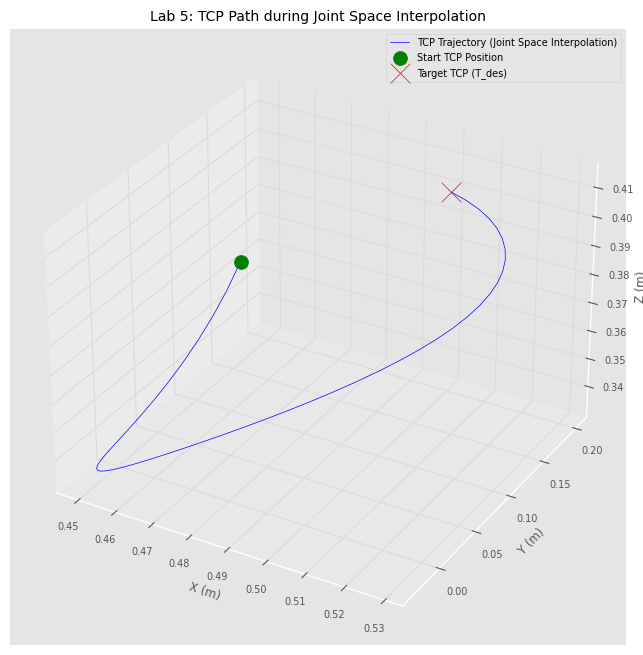


Verification of final pose:
Target T_des position: [0.5 0.2 0.4]
Reached T_final position: [0.5 0.2 0.4]
Position error (Euclidean distance): 7.3145e-12


In [109]:
import roboticstoolbox as rtb
from spatialmath import SE3
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # For 3D plot

# Load robot model (Panda as an example)
robot = rtb.models.URDF.Panda()

print("--- Lab 5: From IK to Real Motion ---")

# 1. Select a target Tdes within the workspace
T_des_lab5 = SE3(0.5, 0.2, 0.4) * SE3.Rx(np.deg2rad(45)) # Example target pose
print(f"\nSelected target pose T_des:\n{T_des_lab5}")

# 2. Read or set qcur as the current configuration
# For demonstration, let's assume it starts from the 'ready' pose
q_cur = robot.qr
print(f"Current joint configuration (q_cur): {np.round(q_cur, 4)}")

# 3. Solve IK: q_des = ikine_LM(T_des, q0=q_cur).q
sol_lab5 = robot.ikine_LM(T_des_lab5, q0=q_cur, ilimit=1000, slimit=100) # Added limits for robustness

if sol_lab5.success:
    q_des = sol_lab5.q
    print(f"IK successful after {sol_lab5.iterations} iterations! Desired joint configuration (q_des): {np.round(q_des, 4)}")

    # 4. Interpolate: q(t) = (1-t)*q_cur + t*q_des for t ∈ [0,1]
    # Create a joint space trajectory
    num_steps = 50
    trajectory_q = np.linspace(q_cur, q_des, num_steps)

    # 5. (Conceptual) Execute trajectory on Swift simulator or Yahboom hardware
    # In Colab, we simulate the forward kinematics to get the TCP path
    tcp_path = []
    for q in trajectory_q:
        T_tcp = robot.fkine(q)
        tcp_path.append(T_tcp.t) # Store the [x, y, z] position of the TCP

    tcp_path = np.array(tcp_path)

    # 6. Plot TCP path in 3D and verify it reaches Tdes
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(tcp_path[:, 0], tcp_path[:, 1], tcp_path[:, 2], 'b-', label='TCP Trajectory (Joint Space Interpolation)')
    ax.scatter(robot.fkine(q_cur).t[0], robot.fkine(q_cur).t[1], robot.fkine(q_cur).t[2], c='g', marker='o', s=100, label='Start TCP Position')
    ax.scatter(T_des_lab5.t[0], T_des_lab5.t[1], T_des_lab5.t[2], c='r', marker='x', s=200, label='Target TCP (T_des)')

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title('Lab 5: TCP Path during Joint Space Interpolation')
    ax.legend()
    ax.grid(True)
    plt.show()

    # Verify final pose
    T_final = robot.fkine(q_des)
    print("\nVerification of final pose:")
    print(f"Target T_des position: {np.round(T_des_lab5.t, 4)}")
    print(f"Reached T_final position: {np.round(T_final.t, 4)}")
    print(f"Position error (Euclidean distance): {np.linalg.norm(T_final.t - T_des_lab5.t):.4e}")

else:
    print(f"IK failed to find a solution for T_des after {sol_lab5.iterations} iterations.")

### Lab 6: Synthesis — Selecting the Best IK Solution

When multiple IK solutions exist for the same Tdes (analytic or numerical with different q₀), we need a principled way to choose the best one for the robot's current state and constraints.
- Proximity to `qcur`: Minimize `‖qsol − qcur‖` to ensure the smallest joint motion and smoothest trajectory.
- Joint Limit Compliance: Reject any solution where any joint angle exceeds its hardware limit. Filter candidates before scoring.
- Singularity Avoidance: Compute det(J·Jᵀ)or manipulability index. Prefer solutions where this is maximized.

Implement a `select_best_ik(solutions, q_cur, joint_limits)` function that returns the optimal solution according to these criteria.

In [110]:
# Assuming 'robot' model is already loaded from Lab 5 (e.g., robot = rtb.models.URDF.Panda())

def select_best_ik(ik_solutions, q_cur, robot_model, weights={'proximity': 1.0, 'manipulability': 0.1}):
    """
    Selects the best IK solution from a list based on given criteria:
    - Proximity to q_cur
    - Joint Limit Compliance
    - Singularity Avoidance (manipulability)

    Args:
        ik_solutions (list): A list of potential joint configurations (np.ndarray).
        q_cur (np.ndarray): The current joint configuration of the robot.
        robot_model (rtb.Robot): The robot model (e.g., rtb.models.URDF.Panda()).
        weights (dict): Dictionary of weights for different criteria (proximity, manipulability).

    Returns:
        np.ndarray: The optimal joint configuration, or None if no valid solution.
    """
    if not ik_solutions:
        return None

    scores = []
    valid_solutions = []

    for q_sol in ik_solutions:
        # 1. Joint Limit Compliance: Reject solutions outside limits
        if not np.all((q_sol >= robot_model.qlim[0]) & (q_sol <= robot_model.qlim[1])):
            # print(f"  Rejected solution due to joint limits: {np.round(q_sol, 4)}")
            continue

        # Valid solution, proceed to scoring
        valid_solutions.append(q_sol)

        # 2. Proximity to q_cur: Minimize ||qsol - qcur||
        proximity_cost = np.linalg.norm(q_sol - q_cur)

        # 3. Singularity Avoidance: Maximize manipulability
        try:
            # Using Yoshikawa's manipulability measure
            manipulability = robot_model.manipulability(q_sol, method='yoshikawa')
        except Exception: # Catch potential errors if q_sol leads to singular Jacobian calculation
            manipulability = 0.001 # Assign a small value to avoid division by zero

        # We want to maximize manipulability, so convert it to a cost to minimize
        # Adding a small epsilon to avoid division by zero if manipulability is 0
        manipulability_cost = 1.0 / (manipulability + 1e-6)

        # Combine costs (lower score is better)
        total_score = (weights.get('proximity', 1.0) * proximity_cost +
                       weights.get('manipulability', 0.1) * manipulability_cost)
        scores.append(total_score)

    if not valid_solutions:
        return None

    # Select the solution with the minimum total score
    best_idx = np.argmin(scores)
    return valid_solutions[best_idx]


# --- Demonstration for Lab 6 ---
print("\n--- Lab 6: Demonstration of Selecting the Best IK Solution ---")

# Define a target pose known to have multiple IK solutions (or likely to)
T_target_lab6 = SE3(0.4, 0.1, 0.5) * SE3.Rx(np.deg2rad(45)) # A central, easily reachable point
print(f"\nTarget pose for finding multiple IK solutions:\n{T_target_lab6}")

# Current robot configuration (for proximity criterion)
q_current_lab6 = robot.qr # 'ready' configuration
print(f"Current robot configuration (q_cur): {np.round(q_current_lab6, 4)}")

# Generate multiple IK solutions by varying the initial guess q0
num_ik_guesses = 10
potential_ik_solutions = []
print("\nGenerating potential IK solutions with different random initial guesses:")
for i in range(num_ik_guesses):
    # Use random initial guesses for a diverse set of solutions within joint limits
    q0_rand = np.random.uniform(robot.qlim[0], robot.qlim[1])
    sol = robot.ikine_LM(T_target_lab6, q0=q0_rand, ilimit=500, slimit=50)
    if sol.success:
        potential_ik_solutions.append(sol.q)
        print(f"  IK solution {i+1} (iterations: {sol.iterations}) found with q0={np.round(q0_rand, 2)}: {np.round(sol.q, 2)}")
    # else:
        print(f"  IK solution {i+1} failed to converge with q0={np.round(q0_rand, 2)}")

print(f"\nFound {len(potential_ik_solutions)} potential IK solutions to evaluate.")

# Select the best solution using the custom function
best_q_solution = select_best_ik(potential_ik_solutions, q_current_lab6, robot)

if best_q_solution is not None:
    print(f"\nBest IK solution selected based on criteria: {np.round(best_q_solution, 4)}")
    # Verify the best solution with FK
    T_check_best = robot.fkine(best_q_solution)
    print(f"Target T_des position: {np.round(T_target_lab6.t, 4)}")
    print(f"Reached T_final position (best solution): {np.round(T_check_best.t, 4)}")
    print(f"Position error for best solution (Euclidean distance): {np.linalg.norm(T_check_best.t - T_target_lab6.t):.4e}")

    # Further analysis of the chosen best solution
    print(f"Proximity to q_cur: {np.linalg.norm(best_q_solution - q_current_lab6):.4f}")
    print(f"Manipulability (Yoshikawa): {robot.manipulability(best_q_solution, method='yoshikawa'):.4f}")

else:
    print("No valid IK solution could be selected from the candidates.")


--- Lab 6: Demonstration of Selecting the Best IK Solution ---

Target pose for finding multiple IK solutions:
   1         0         0         0.4       
   0         0.7071   -0.7071    0.1       
   0         0.7071    0.7071    0.5       
   0         0         0         1         

Current robot configuration (q_cur): [ 0.     -0.3     0.     -2.2     0.      2.      0.7854]

Generating potential IK solutions with different random initial guesses:
  IK solution 1 (iterations: 123) found with q0=[-2.33 -0.93  1.72 -0.29  2.01  1.74 -0.59]: [ 2.7  -0.36 -1.93 -2.37 -2.    0.29  1.18]
  IK solution 1 failed to converge with q0=[-2.33 -0.93  1.72 -0.29  2.01  1.74 -0.59]
  IK solution 2 (iterations: 25) found with q0=[ 0.99 -1.18  1.94 -0.54 -0.13  2.81 -2.54]: [-1.12 -0.71  1.69 -2.34 -1.34  1.17  1.28]
  IK solution 2 failed to converge with q0=[ 0.99 -1.18  1.94 -0.54 -0.13  2.81 -2.54]
  IK solution 3 (iterations: 29) found with q0=[-0.81 -1.3  -1.29 -1.1  -0.26  2.89  1.62]: [ 1

### Extra Lab



**Mobile "IK" — From `(v, ω)` to `(vL, vR)`**

Tasks
1. Implement `diff_drive_ik(v, w, W)`
2. Create a motion profile: constant v, constant ω
3. Simulate trajectory `(x(t), y(t), θ(t))` using the unicycle model
4. Try multiple ω values and observe varying turning radius: $R_{turn} = v/\omega$

In [111]:
def diff_drive_ik(v, w, W):
    """
    Convert desired body velocity (v, w) to wheel speeds (v_L, v_R).
    Args:
    v : forward speed [m/s]
    w : angular rate [rad/s]
    W : wheel track width [m]
    Returns:
    v_L, v_R : left and right wheel speeds [m/s]
    """
    v_R = v + w * W / 2
    v_L = v - w * W / 2
    return v_L, v_R

Expected Observations

- `ω = 0`: Straight line (`vL = vR`)
- `ω` small: Large turning radius (gentle curve)
- `ω` large: Small turning radius (tight circle)
- `ω = v/r`: Circle of radius `r`
- `v = 0, ω ≠ 0`: Spin in place

**Line Following 1D Simulation**

In [112]:
import numpy as np
def simulate_line_following(e_series, ke, v0, W, dt=0.1):
    """
    e_series : array of lateral errors [pixels]
    ke  : proportional gain [rad/s per pixel]
    v0  : constant forward speed [m/s]
    W   : wheel track width [m]
    0.0
    """
    x, y, theta = 0.0, 0.0, 0.0
    trajectory = [(x, y, theta)]

    for e in e_series:
        omega = ke * e
        v_L, v_R = diff_drive_ik(v0, omega, W)
        # Unicycle step
        x += v0 * np.cos(theta) * dt
        y += v0 * np.sin(theta) * dt
        theta += omega * dt
        trajectory.append((x, y, theta))

    return trajectory

Simulating with Step Error...


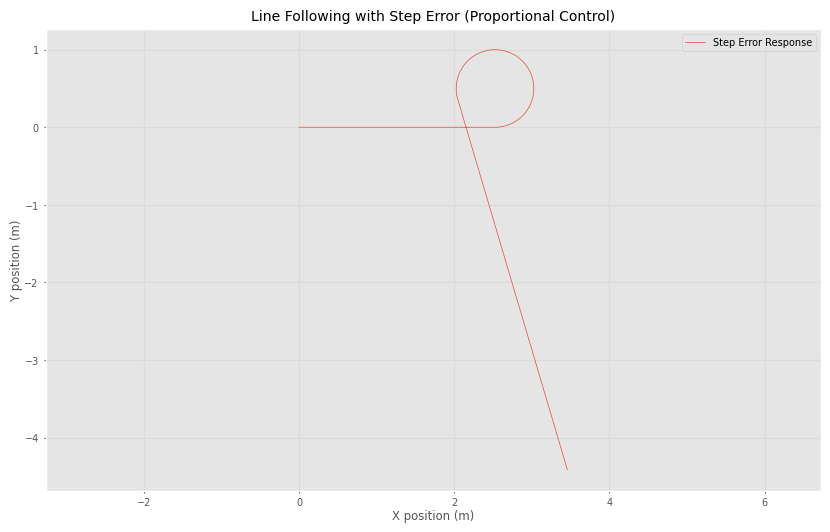

Simulating with Sinusoidal Error...


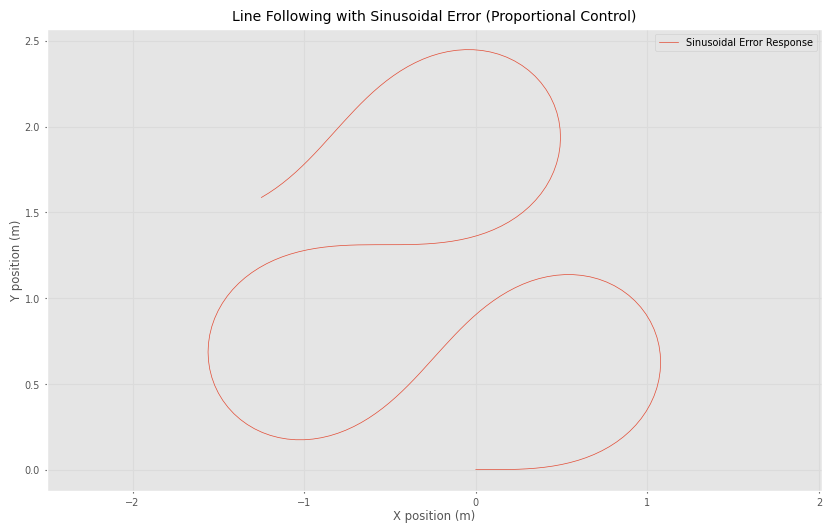

Simulating with Random Noise...


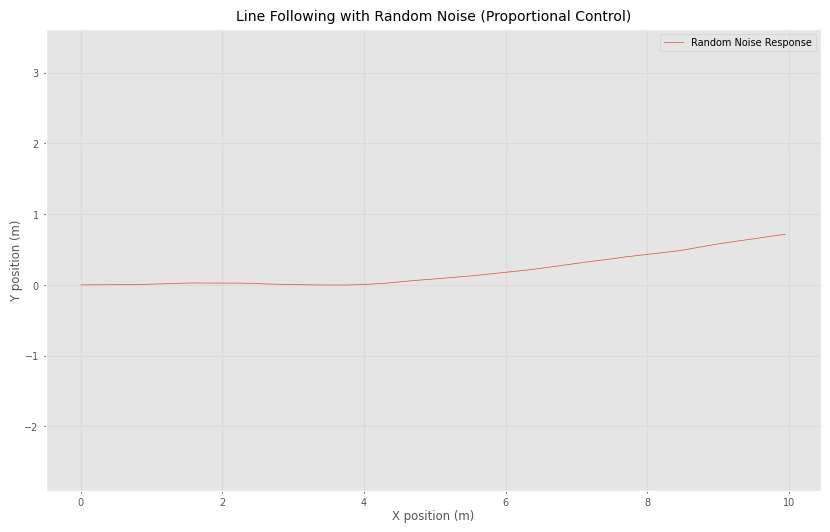

In [113]:
# Test with: step error (sudden offset), sinusoidal error (winding path), and small random noise. Observe how the proportional controller drives the robot back toward the line.
import matplotlib.pyplot as plt

# Define parameters for simulation
v0 = 0.5  # m/s
W = 0.3   # m
ke = 0.1  # Proportional gain [rad/s per pixel] (assuming pixel error scales to rad/s)
dt = 0.1  # seconds
duration = 20 # seconds
time_steps = int(duration / dt)

# Test Case 1: Step error (sudden offset)
print("Simulating with Step Error...")
e_step = np.zeros(time_steps)
e_step[int(time_steps / 4):int(time_steps / 2)] = 10 # 10 pixel offset for a duration
trajectory_step = simulate_line_following(e_step, ke, v0, W, dt)
x_step, y_step, _ = zip(*trajectory_step)

plt.figure(figsize=(10, 6))
plt.plot(x_step, y_step, label='Step Error Response')
plt.title('Line Following with Step Error (Proportional Control)')
plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

# Test Case 2: Sinusoidal error (winding path)
print("Simulating with Sinusoidal Error...")
t = np.linspace(0, duration, time_steps)
e_sinusoidal = 10 * np.sin(t * 0.5) # Sinusoidal error
trajectory_sinusoidal = simulate_line_following(e_sinusoidal, ke, v0, W, dt)
x_sin, y_sin, _ = zip(*trajectory_sinusoidal)

plt.figure(figsize=(10, 6))
plt.plot(x_sin, y_sin, label='Sinusoidal Error Response')
plt.title('Line Following with Sinusoidal Error (Proportional Control)')
plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

# Test Case 3: Small random noise
print("Simulating with Random Noise...")
e_noise = np.random.normal(0, 1, time_steps) # Gaussian noise with mean 0, std dev 1
trajectory_noise = simulate_line_following(e_noise, ke, v0, W, dt)
x_noise, y_noise, _ = zip(*trajectory_noise)

plt.figure(figsize=(10, 6))
plt.plot(x_noise, y_noise, label='Random Noise Response')
plt.title('Line Following with Random Noise (Proportional Control)')
plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

**Saturation on v and ω in Line Following**
Real motors have maximum speeds. If the controller produces `|ω| > ωmax` or `|v| > vmax`, the command is clipped — introducing nonlinearity that affects stability and tracking quality.

Without saturation: 
- Large errors cause violent steering — the robot may oscillate or overshoot
- With saturation: Motion is bounded but may be slower to correct large errors
- Trade-off: Stability vs. response speed vs. hardware constraints

In [114]:
# omega = np.clip(ke * e, -w_max, w_max)
# v = np.clip(v0, -v_max, v_max)

If `k_e` is too large even with saturation, then the robot will still oscillate, but the amplitude will be limited by the saturation. If `k_e` is too small, the robot will respond sluggishly to errors, leading to poor tracking performance. Tuning `k_e` is essential to achieve a balance between responsiveness and stability in the presence of saturation.

**Connecting Simulation to Real JetRacer / TurtleBot**

- Camera: Captures image frame at 30 FPS. Detects lane center and computes pixel error `e(t)` via image processing.
- Controller: `ω(t) = ke · e(t)`, clipped to ±ωmax. Identical code runs in simulation and on hardware.
- diff_drive_ik: Converts (v, ω) to (vL, vR). Same function used in simulation and on the real robot.
- Motors: Wheel speed commands sent to hardware via ROS topic or SDK. Robot drives along the line.

The pipeline is identical between simulation and hardware — only the camera input source changes. This validates the simulation workflow for real deployment.